<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Validation NuSQuIDS 4: Solar Neutrino Earth Detection
---

This notebook validates the **Earth-detection stage** of solar neutrinos by comparing
`TPeanuts` and `nuSQuIDS` after the neutrino has already exited the Sun as an
**incoherent vacuum-mass mixture**. To avoid repeating the solar-model mismatch already
studied in `nusquids2_solar`, both backends receive the **same TPeanuts solar mass
weights** $w_i(E)$ as input. The comparison therefore isolates:

1. Earth matter regeneration for a fixed nadir angle.
2. Annual exposure-averaged detector probabilities.
3. Detector-level $
u_e$ flux and an elastic-scattering event-rate proxy.
4. Annual event counts in representative detectors using the same response model.

## Table of Contents

| ? | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** ? decohered solar input state, Earth regeneration, detector response |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Fixed-Nadir-Earth-Probability) | **Fixed-Nadir Earth Probability** |
| [4](#4.-Exposure-Averaged-Detector-Probability) | **Exposure-Averaged Detector Probability** |
| [5](#5.-Detector-Flux-and-Rate-Proxy) | **Detector Flux and Rate Proxy** |
| [6](#6.-Annual-Event-Counts) | **Annual Event Counts** |
| [7](#7.-Export-Tables) | **Export Tables** |
| [8](#8.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Common Solar Input State

A solar neutrino produced as $
u_e$ exits the Sun as an **incoherent mixture of vacuum
mass eigenstates** after MSW evolution and Sun-Earth decoherence,

$$
w_i(E) = P(
u_e^\odot 	o 
u_i) .
$$

In this notebook the same $w_i(E)$ from `tpeanuts.medium.solar.probability.solar_probability_mass`
is fed to both Earth solvers. This removes the known difference between the B16 AGSS09
solar model used by TPeanuts and the internal `SunASnu` model used by nuSQuIDS, so the
comparison focuses only on the **Earth detection stage**.

### 0.2 Earth Regeneration and Nadir Mapping

Inside the Earth, each vacuum mass eigenstate propagates coherently through the matter
profile. For an incoherent input mixture, the detector flavour probability is

$$
P_\alpha^{\rm det}(E,\eta) = \sum_{i=1}^3 T_{\alpha i}^{\oplus}(E,\eta)\, w_i(E),
$$

where $T_{\alpha i}^{\oplus}$ is the Earth transition probability matrix from the
initial vacuum-mass basis to the final flavour basis. Solar nadir angle $\eta$ is mapped
to the detector zenith convention used by nuSQuIDS as

$$
\cos	heta_z = -\cos\eta,
$$

so $\eta=0$ corresponds to a core-crossing night trajectory and $\eta=\pi/2$ to the
horizon. In the nuSQuIDS `Earth` backend this angle is not passed as an atmosphere
production direction; it is converted to an Earth-only chord baseline,

$$
L_{\oplus}(\eta) = \max\bigl(0,\,2 R_{\oplus}\cos\eta\bigr)
                 = \max\bigl(0,\,-2 R_{\oplus}\cos\theta_z\bigr),
$$

and the nuSQuIDS track is constructed as `Earth.Track(L_\oplus)`. This keeps the
reference calculation as a solar-neutrino Earth-regeneration problem rather than an
atmospheric-neutrino propagation setup.

### 0.3 Detector Flux and Event-Rate Proxy

For the $^8$B source, the annually averaged detector-side electron-neutrino flux is

$$
\Phi_e^{\rm det}(E) = \Phi_{^8\mathrm{B}}\, g_{^8\mathrm{B}}(E)\, \langle P_{ee}(E) \rangle,
$$

where $g_{^8\mathrm{B}}(E)$ is the normalized source spectrum. To compare detector-level
observables with the same post-processing on both backends, we use the standard elastic
scattering proxy

$$
\sigma_{\rm eff}(E) = P_{ee}(E)\,\sigma_e(E) + \bigl(1-P_{ee}(E)\bigr)\,\sigma_{\mu	au}(E),
$$

with the linear approximations

$$
\sigma_e(E) \simeq 9.20	imes10^{-45}\,E_{\rm MeV}\;\mathrm{cm}^2,
\qquad
\sigma_{\mu	au}(E) \simeq 1.57	imes10^{-45}\,E_{\rm MeV}\;\mathrm{cm}^2 .
$$

The annual event count is then estimated as

$$
N_{\rm yr} = N_e\, T_{\rm yr}\, \int dE\; \Phi_{^8\mathrm{B}} g_{^8\mathrm{B}}(E)\, \sigma_{\rm eff}(E),
$$

where $N_e$ is the number of target electrons in the detector. This is a shared detector
model applied after propagation; it is not a native nuSQuIDS detector module.

### References

- L. Wolfenstein (1978), *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369.
- S. P. Mikheyev and A. Yu. Smirnov (1985), *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*, Sov. J. Nucl. Phys. **42**, 913.
- L. Stodolsky (1975), *When the wavepacket is unnecessary*, Phys. Rev. D **58**, 036006.
- W. C. Haxton (1986), *Adiabatic conversion of solar neutrinos*, Phys. Rev. Lett. **57**, 1271.
- J. N. Bahcall and C. Pena-Garay (2004), *Solar models and solar neutrino oscillations*, New J. Phys. **6**, 63.
- C. A. Arguelles, J. Salvado, and C. N. Weaver (2022), *nuSQuIDS: A toolbox for neutrino propagation*, Comput. Phys. Commun. **277**, 108346.

## 1. Libraries

In [1]:
from __future__ import annotations

%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import trapezoid

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_LABELS,
    FLAVOUR_COLORS,
    to_numpy,
    add_tolerance_lines,
    save_and_show,
    compare_probability_grids,
    status_from_rel,
)
from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig,
    NuSQuIDSError,
    is_available as nusquids_is_available,
    probability_earth_massbasis,
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import pearth_analytical
from tpeanuts.medium.earth.exposure_table import ExposureParameters, build_nadir_exposure

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared plotting style,
and creates the notebook output directory. All figures and CSV files from this notebook are
written under `validation/nusquids/` with the `vn4_` prefix.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("validation", "nusquids")
SHOW       = config.show_plots

print(f"Device : {ctx.device}   dtype : {ctx.dtype}")
print(f"Output : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {nusquids_is_available()}")

Device : cpu   dtype : torch.float64
Output : /mnt/v/output/validation/nusquids
nuSQuIDS available: True


### 2.2 Configuration

The benchmark uses **$^8$B solar neutrinos**, because they dominate the measurable
high-energy solar signal in water and scintillator detectors. The Earth stage is compared
for four representative detector latitudes. The detector count prediction uses the same
elastic-scattering response model on top of both propagation backends, so any difference
comes only from the predicted $P_{ee}(E)$.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| Source | `8B` | Dominant measurable high-energy solar source |
| Energy grids | fixed: 24 pts, annual: 18 pts | 2-16 MeV comparison window |
| Earth profile | `even_power` PREM fit | Same TPeanuts Earth profile as analysis notebooks |
| Detector depth | 2000 m | Underground reference depth |
| Exposure integration | 41 nadir samples | Manual `trapezoid` quadrature |
| nuSQuIDS tolerances | rel=1e-6, abs=1e-8 | Earth reference backend |
| Detector response | ES proxy | $\sigma_e$, $\sigma_{\mu	au}$ linear approximation |

The detector masses and target-electron counts below are **nominal fiducial values** used
only to convert the common event-rate proxy into annual counts. They do not affect the
backend-to-backend validation logic.

In [3]:
oscillation = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
solar_profile = SolarProfile.default(context=ctx)
earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={
            "density_file": str(config.earth_density_file),
            "tabulated_density": False,
        },
    ),
    context=ctx,
)

SOURCE = "8B"
EARTH_DEPTH_M = 2000.0
EXPOSURE_NS = 41
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
SIGMA_E_0 = 9.20e-45
SIGMA_MUTAU_0 = 1.57e-45
NSQ_CONFIG = NuSQuIDSConfig(rel_error=1.0e-6, abs_error=1.0e-8)

E_FIXED_MEV = np.linspace(2.0, 16.0, 24)
E_ANNUAL_MEV = np.linspace(2.0, 16.0, 18)
ETA_CASES = [
    (0.10 * math.pi, r"Core-crossing ($\eta=0.10\pi$)", "C0"),
    (0.20 * math.pi, r"Outer core ($\eta=0.20\pi$)", "C1"),
    (0.33 * math.pi, r"Mantle ($\eta=0.33\pi$)", "C2"),
    (0.45 * math.pi, r"Grazing night ($\eta=0.45\pi$)", "C3"),
]

DETECTORS = {
    "Super-K": {
        "lat_deg": 36.43,
        "color": "C0",
        "mass_kt": 22.5,
        "material": "water",
    },
    "Borexino": {
        "lat_deg": 42.45,
        "color": "C1",
        "mass_kt": 0.278,
        "material": "pseudocumene",
    },
    "SNO+": {
        "lat_deg": 46.47,
        "color": "C2",
        "mass_kt": 0.780,
        "material": "lab",
    },
    "JUNO": {
        "lat_deg": 22.12,
        "color": "C3",
        "mass_kt": 20.0,
        "material": "lab",
    },
}

MATERIALS = {
    "water": {"molar_mass_g": 18.01528, "electrons": 10},
    "pseudocumene": {"molar_mass_g": 120.19, "electrons": 66},
    "lab": {"molar_mass_g": 246.43, "electrons": 138},
}

spec_df = pd.read_csv(config.package_dir / "data" / "solar" / "spectra" / "spectrum_8B.csv")
G_8B_E = spec_df["Energy"].to_numpy(dtype=float)
G_8B_SPEC = spec_df["Spectrum"].to_numpy(dtype=float)
G_8B_SPEC = G_8B_SPEC / trapezoid(G_8B_SPEC, x=G_8B_E)
PHI_8B = float(solar_profile.fluxes[SOURCE])
VACUUM_PROJECTOR = to_numpy(oscillation.pmns.vacuum_flavour_projector())

print(f"Preset       : {oscillation.preset_name}")
print(f"Source       : {SOURCE}")
print(f"Phi_8B       : {PHI_8B:.4e} cm^-2 s^-1")
print(f"int g_8B dE  : {trapezoid(G_8B_SPEC, x=G_8B_E):.6f}")
for det_name, det in DETECTORS.items():
    print(f"{det_name:10s}  lat={det['lat_deg']:5.2f} deg   mass={det['mass_kt']:6.3f} kt   material={det['material']}")

Preset       : _SM_NUFIT52_NO
Source       : 8B
Phi_8B       : 4.1350e+06 cm^-2 s^-1
int g_8B dE  : 1.000000
Super-K     lat=36.43 deg   mass=22.500 kt   material=water
Borexino    lat=42.45 deg   mass= 0.278 kt   material=pseudocumene
SNO+        lat=46.47 deg   mass= 0.780 kt   material=lab
JUNO        lat=22.12 deg   mass=20.000 kt   material=lab


### 2.3 Helpers

The helper layer is intentionally small. It does three things only:

1. build the common solar mass weights $w_i(E)$ from TPeanuts,
2. propagate those weights through the Earth with either backend,
3. apply the same exposure and detector-response post-processing to both.

In [4]:
AVOGADRO = 6.02214076e23


def cos_zenith_from_nadir(eta_rad: float) -> float:
    return -math.cos(float(eta_rad))



def electron_targets(detector: dict) -> float:
    material = MATERIALS[detector["material"]]
    mass_g = float(detector["mass_kt"]) * 1.0e9
    molecules = mass_g / material["molar_mass_g"] * AVOGADRO
    return molecules * material["electrons"]



def tp_mass_weights(E_MeV_np: np.ndarray) -> np.ndarray:
    E_t = torch.as_tensor(E_MeV_np, dtype=ctx.dtype, device=ctx.device)
    return to_numpy(solar_probability_mass(oscillation, E_t, solar_profile, SOURCE))



def tp_day_probabilities(E_MeV_np: np.ndarray) -> np.ndarray:
    weights = tp_mass_weights(E_MeV_np)
    return weights @ VACUUM_PROJECTOR.T



def tp_earth_probabilities(E_MeV_np: np.ndarray, eta_rad: float) -> np.ndarray:
    E_t = torch.as_tensor(E_MeV_np, dtype=ctx.dtype, device=ctx.device)
    w_t = solar_probability_mass(oscillation, E_t, solar_profile, SOURCE)
    eta_t = torch.tensor(float(eta_rad), dtype=ctx.dtype, device=ctx.device)
    return to_numpy(
        pearth_analytical(
            w_t,
            earth_profile,
            oscillation,
            E_t,
            eta_t,
            EARTH_DEPTH_M,
            massbasis=True,
        )
    )



def nsq_earth_probabilities(E_MeV_np: np.ndarray, eta_rad: float) -> np.ndarray:
    if not nusquids_is_available():
        return np.full((len(E_MeV_np), 3), np.nan, dtype=float)

    weights = tp_mass_weights(E_MeV_np)
    out = np.zeros((len(E_MeV_np), 3), dtype=float)
    cosz = cos_zenith_from_nadir(eta_rad)
    try:
        for idx, energy in enumerate(E_MeV_np):
            out[idx] = probability_earth_massbasis(
                E_GeV=float(energy) * 1.0e-3,
                cos_zenith=cosz,
                mass_weights=weights[idx],
                antinu=False,
                config=NSQ_CONFIG,
            )
    except NuSQuIDSError as exc:
        print(f"nuSQuIDS Earth mass-basis propagation unavailable: {exc}")
        return np.full((len(E_MeV_np), 3), np.nan, dtype=float)
    return out



def exposure_grid(detector_name: str) -> tuple[np.ndarray, np.ndarray]:
    exposure = ExposureParameters(
        detector_latitude_rad=math.radians(DETECTORS[detector_name]["lat_deg"]),
        exposure_daynight="night",
        exposure_ns=EXPOSURE_NS,
    )
    table = build_nadir_exposure(exposure=exposure, context=ctx, normalized=True)
    return to_numpy(table.eta), to_numpy(table.exposure)



def annual_average_probabilities(backend: str, E_MeV_np: np.ndarray, detector_name: str) -> np.ndarray:
    eta_grid, w_eta = exposure_grid(detector_name)
    stack = []
    for eta in eta_grid:
        if backend == "tpeanuts":
            probs = tp_earth_probabilities(E_MeV_np, float(eta))
        elif backend == "nusquids":
            probs = nsq_earth_probabilities(E_MeV_np, float(eta))
        else:
            raise ValueError("backend must be 'tpeanuts' or 'nusquids'.")
        stack.append(probs)
    stack_np = np.stack(stack, axis=0)
    return trapezoid(stack_np * w_eta[:, None, None], x=eta_grid, axis=0)



def interp_b8_spectrum(E_MeV_np: np.ndarray) -> np.ndarray:
    return np.interp(E_MeV_np, G_8B_E, G_8B_SPEC, left=0.0, right=0.0)



def annual_flux_nue(P_avg: np.ndarray, E_MeV_np: np.ndarray) -> np.ndarray:
    g = interp_b8_spectrum(E_MeV_np)
    return PHI_8B * g * P_avg[:, 0]



def annual_rate_proxy(P_avg: np.ndarray, E_MeV_np: np.ndarray) -> np.ndarray:
    g = interp_b8_spectrum(E_MeV_np)
    sigma_e = SIGMA_E_0 * E_MeV_np
    sigma_mutau = SIGMA_MUTAU_0 * E_MeV_np
    sigma_eff = P_avg[:, 0] * sigma_e + (1.0 - P_avg[:, 0]) * sigma_mutau
    return PHI_8B * g * sigma_eff



def scalar_comparison(tp_df: pd.DataFrame, nsq_df: pd.DataFrame, key_cols, value_col: str) -> pd.DataFrame:
    tp_one = tp_df.rename(columns={value_col: "P_nue"})
    nsq_one = nsq_df.rename(columns={value_col: "P_nue"})
    return compare_probability_grids(tp_one, nsq_one, key_cols, prob_cols=("P_nue",))

## 3. Fixed-Nadir Earth Probability

This section compares the detector flavour probabilities at four fixed nadir angles using
exactly the same solar-exit mass weights as input to both backends.

**Expected results:**
- The curves should agree very closely because the solar stage is held fixed.
- Differences, if any, should now reflect only the Earth propagation model and numerical implementation.
- The largest regeneration effect should appear for the smallest nadir angles, i.e. the deepest night trajectories.

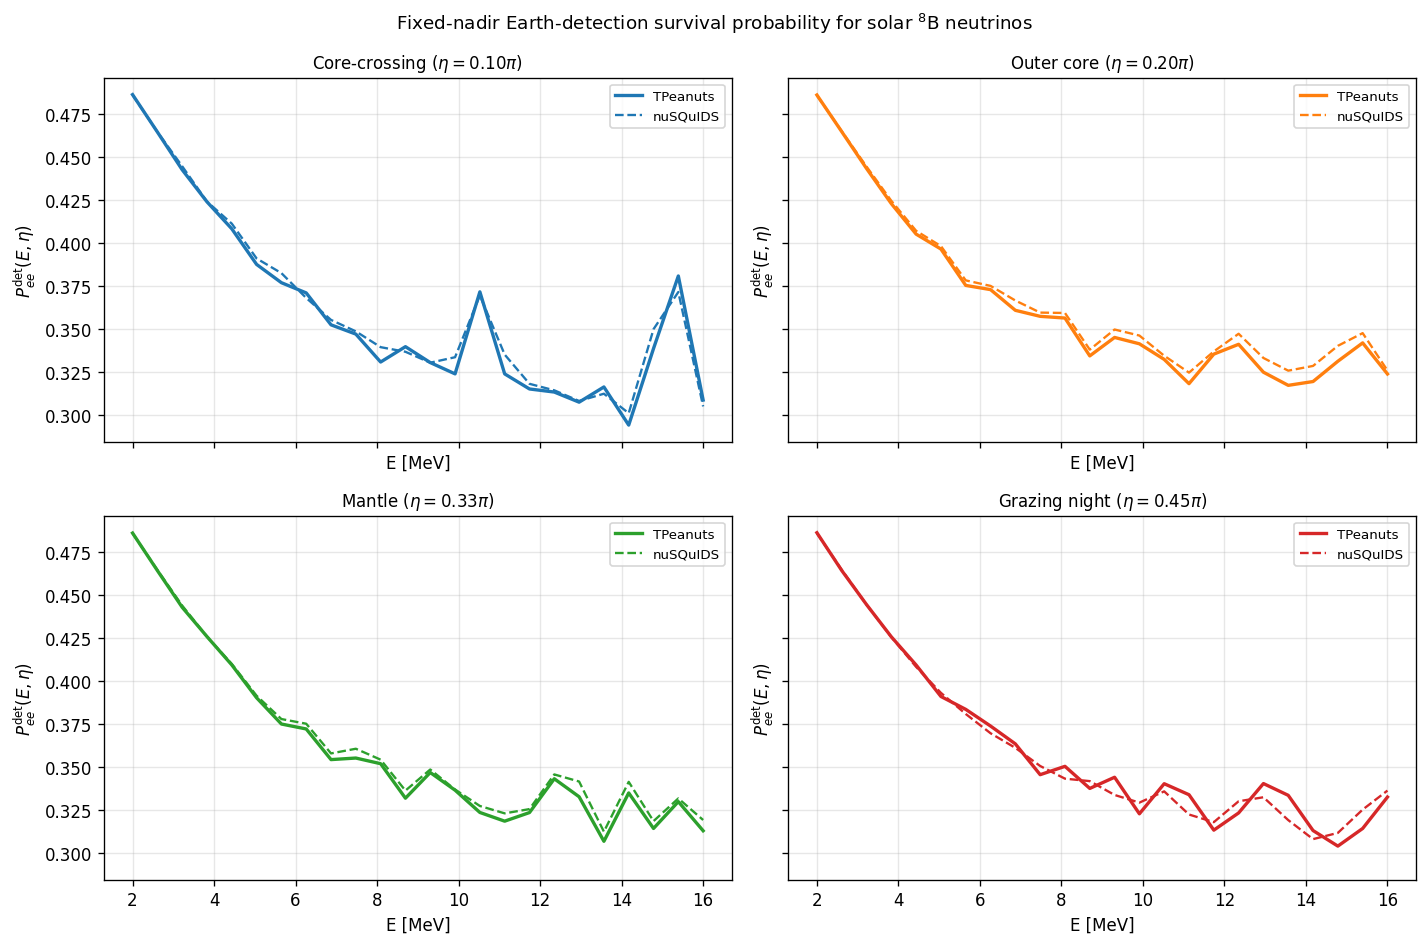

/mnt/v/output/validation/nusquids/vn4_fig31_fixed_nadir_probability.png


,eta_over_pi,max_rel_err
0,0.10,0.146680
1,0.20,0.148093
2,0.33,0.146865
3,0.45,0.146366


In [5]:
fixed_rows_tp = []
fixed_rows_nsq = []
fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex=True, sharey=True)

for ax, (eta_val, eta_label, color) in zip(axes.flat, ETA_CASES):
    tp_prob = tp_earth_probabilities(E_FIXED_MEV, eta_val)
    nsq_prob = nsq_earth_probabilities(E_FIXED_MEV, eta_val)

    ax.plot(E_FIXED_MEV, tp_prob[:, 0], color=color, lw=2.0, label="TPeanuts")
    ax.plot(E_FIXED_MEV, nsq_prob[:, 0], color=color, lw=1.4, ls="--", label="nuSQuIDS")
    ax.set_title(eta_label, fontsize=10)
    ax.set_xlabel("E [MeV]")
    ax.set_ylabel(r"$P_{ee}^{\rm det}(E,\eta)$")
    ax.legend(fontsize=8)

    for i, energy in enumerate(E_FIXED_MEV):
        fixed_rows_tp.append({
            "backend": "tpeanuts",
            "quantity": "fixed_eta_probability",
            "eta_over_pi": eta_val / math.pi,
            "E_MeV": float(energy),
            "P_nue": tp_prob[i, 0],
            "P_numu": tp_prob[i, 1],
            "P_nutau": tp_prob[i, 2],
        })
        fixed_rows_nsq.append({
            "backend": "nuSQuIDS",
            "quantity": "fixed_eta_probability",
            "eta_over_pi": eta_val / math.pi,
            "E_MeV": float(energy),
            "P_nue": nsq_prob[i, 0],
            "P_numu": nsq_prob[i, 1],
            "P_nutau": nsq_prob[i, 2],
        })

fig.suptitle(r"Fixed-nadir Earth-detection survival probability for solar $^8$B neutrinos", fontsize=11)
fig.tight_layout()
save_and_show("vn4_fig31_fixed_nadir_probability.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

fixed_tp_df = pd.DataFrame.from_records(fixed_rows_tp)
fixed_nsq_df = pd.DataFrame.from_records(fixed_rows_nsq)
fixed_cmp = compare_probability_grids(
    fixed_tp_df,
    fixed_nsq_df,
    ["quantity", "eta_over_pi", "E_MeV"],
)

fixed_summary = (
    fixed_cmp.groupby("eta_over_pi", as_index=False)["max_rel_err"]
    .max()
    .sort_values("eta_over_pi")
)
display(fixed_summary)

## 4. Exposure-Averaged Detector Probability

The observable night probability depends on the detector latitude through the nadir-angle
exposure. Here both backends are averaged over the **same exposure table** using manual
`trapezoid` quadrature, so the comparison still isolates the Earth solver.

**Expected results:**
- The annually averaged $\langle P_{ee}\rangle$ should differ only slightly from one detector to another.
- Lower latitudes should show a slightly stronger regeneration effect because they sample deeper night trajectories more often.
- Backend agreement should remain much tighter than in `nusquids2`, where the solar model itself also differed.

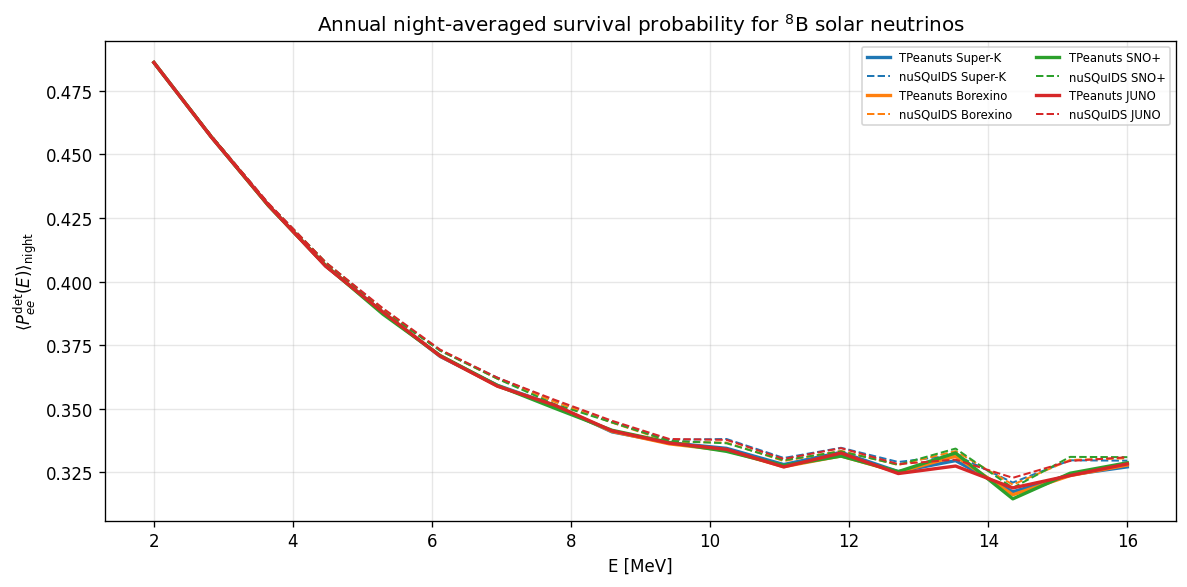

/mnt/v/output/validation/nusquids/vn4_fig41_annual_probability.png


,detector,max_rel_err
2,SNO+,0.146640
3,Super-K,0.146635
0,Borexino,0.146633
1,JUNO,0.146628


In [6]:
annual_tp = {}
annual_nsq = {}
annual_rows_tp = []
annual_rows_nsq = []

fig, ax = plt.subplots(figsize=(10.0, 5.0))
for det_name, det in DETECTORS.items():
    tp_prob = annual_average_probabilities("tpeanuts", E_ANNUAL_MEV, det_name)
    nsq_prob = annual_average_probabilities("nusquids", E_ANNUAL_MEV, det_name)
    annual_tp[det_name] = tp_prob
    annual_nsq[det_name] = nsq_prob

    ax.plot(E_ANNUAL_MEV, tp_prob[:, 0], color=det["color"], lw=2.0, label=f"TPeanuts {det_name}")
    ax.plot(E_ANNUAL_MEV, nsq_prob[:, 0], color=det["color"], lw=1.2, ls="--", label=f"nuSQuIDS {det_name}")

    for i, energy in enumerate(E_ANNUAL_MEV):
        annual_rows_tp.append({
            "backend": "tpeanuts",
            "quantity": "annual_detector_probability",
            "detector": det_name,
            "E_MeV": float(energy),
            "P_nue": tp_prob[i, 0],
            "P_numu": tp_prob[i, 1],
            "P_nutau": tp_prob[i, 2],
        })
        annual_rows_nsq.append({
            "backend": "nuSQuIDS",
            "quantity": "annual_detector_probability",
            "detector": det_name,
            "E_MeV": float(energy),
            "P_nue": nsq_prob[i, 0],
            "P_numu": nsq_prob[i, 1],
            "P_nutau": nsq_prob[i, 2],
        })

ax.set_xlabel("E [MeV]")
ax.set_ylabel(r"$\langle P_{ee}^{\rm det}(E)\rangle_{\rm night}$")
ax.set_title(r"Annual night-averaged survival probability for $^8$B solar neutrinos")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
save_and_show("vn4_fig41_annual_probability.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

annual_tp_df = pd.DataFrame.from_records(annual_rows_tp)
annual_nsq_df = pd.DataFrame.from_records(annual_rows_nsq)
annual_cmp = compare_probability_grids(
    annual_tp_df,
    annual_nsq_df,
    ["quantity", "detector", "E_MeV"],
)

annual_summary = (
    annual_cmp.groupby("detector", as_index=False)["max_rel_err"]
    .max()
    .sort_values("max_rel_err", ascending=False)
)
display(annual_summary)

## 5. Detector Flux and Rate Proxy

This section turns the annually averaged probability into detector-side observables for a
single benchmark detector, **Super-K**, using the same $^8$B source spectrum and the same
elastic-scattering proxy on both backends.

**Expected results:**
- The $
u_e$ flux tracks the shape of $g_{^8\rm B}(E)$ modulated by $\langle P_{ee}\rangle$.
- The rate proxy weights high energies more strongly because the scattering cross section grows linearly with $E$.
- Any backend difference should stay at the probability-comparison level, since the detector response is shared.

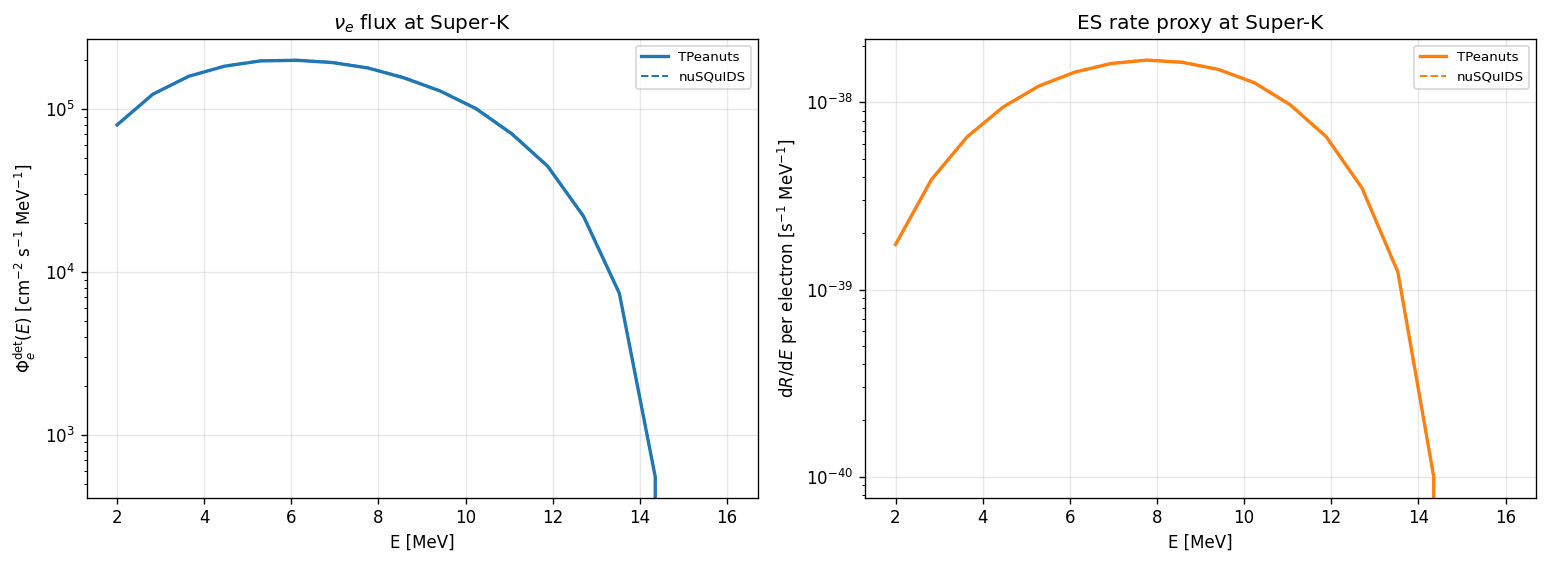

/mnt/v/output/validation/nusquids/vn4_fig51_flux_rate_proxy_superk.png


,quantity,max_rel_err
0,flux_nue,1.151676e-02
1,rate_proxy,1.130743e-28


In [7]:
BENCHMARK_DETECTOR = "Super-K"
P_tp_bench = annual_tp[BENCHMARK_DETECTOR]
P_nsq_bench = annual_nsq[BENCHMARK_DETECTOR]

flux_tp = annual_flux_nue(P_tp_bench, E_ANNUAL_MEV)
flux_nsq = annual_flux_nue(P_nsq_bench, E_ANNUAL_MEV)
rate_tp = annual_rate_proxy(P_tp_bench, E_ANNUAL_MEV)
rate_nsq = annual_rate_proxy(P_nsq_bench, E_ANNUAL_MEV)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(E_ANNUAL_MEV, flux_tp, color="C0", lw=2.0, label="TPeanuts")
axes[0].plot(E_ANNUAL_MEV, flux_nsq, color="C0", lw=1.2, ls="--", label="nuSQuIDS")
axes[0].set_xlabel("E [MeV]")
axes[0].set_ylabel(r"$\Phi_e^{\rm det}(E)$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
axes[0].set_title(rf"$\nu_e$ flux at {BENCHMARK_DETECTOR}")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

axes[1].plot(E_ANNUAL_MEV, rate_tp, color="C1", lw=2.0, label="TPeanuts")
axes[1].plot(E_ANNUAL_MEV, rate_nsq, color="C1", lw=1.2, ls="--", label="nuSQuIDS")
axes[1].set_xlabel("E [MeV]")
axes[1].set_ylabel(r"${\rm d}R/{\rm d}E$ per electron [s$^{-1}$ MeV$^{-1}$]")
axes[1].set_title(rf"ES rate proxy at {BENCHMARK_DETECTOR}")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_and_show("vn4_fig51_flux_rate_proxy_superk.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

flux_tp_df = pd.DataFrame({
    "quantity": "benchmark_flux_nue",
    "detector": BENCHMARK_DETECTOR,
    "E_MeV": E_ANNUAL_MEV,
    "flux_nue": flux_tp,
})
flux_nsq_df = pd.DataFrame({
    "quantity": "benchmark_flux_nue",
    "detector": BENCHMARK_DETECTOR,
    "E_MeV": E_ANNUAL_MEV,
    "flux_nue": flux_nsq,
})
flux_cmp = scalar_comparison(flux_tp_df, flux_nsq_df, ["quantity", "detector", "E_MeV"], "flux_nue")

rate_tp_df = pd.DataFrame({
    "quantity": "benchmark_rate_proxy",
    "detector": BENCHMARK_DETECTOR,
    "E_MeV": E_ANNUAL_MEV,
    "rate_total": rate_tp,
})
rate_nsq_df = pd.DataFrame({
    "quantity": "benchmark_rate_proxy",
    "detector": BENCHMARK_DETECTOR,
    "E_MeV": E_ANNUAL_MEV,
    "rate_total": rate_nsq,
})
rate_cmp = scalar_comparison(rate_tp_df, rate_nsq_df, ["quantity", "detector", "E_MeV"], "rate_total")

display(
    pd.DataFrame({
        "quantity": ["flux_nue", "rate_proxy"],
        "max_rel_err": [flux_cmp["max_rel_err"].max(), rate_cmp["max_rel_err"].max()],
    })
)

## 6. Annual Event Counts

Using the same detector-response model, we now integrate the annual rate proxy over energy
and scale it by the nominal number of target electrons in each detector.

**Expected results:**
- The absolute count scale is dominated by fiducial mass and target-electron count, not by latitude.
- Latitude changes should still appear at the percent level through Earth regeneration.
- Backend agreement should remain as good as the underlying probability comparison because the detector model is identical on both sides.

,quantity,detector,annual_events_tp,target_electrons,annual_events_nsq
0,annual_events,Super-K,28462.767840,7.521291e+33,28576.120964
1,annual_events,Borexino,347.732427,9.193297e+31,349.000413
2,annual_events,SNO+,995.001656,2.630456e+32,998.380418
3,annual_events,JUNO,25518.094848,6.744759e+33,25632.040746


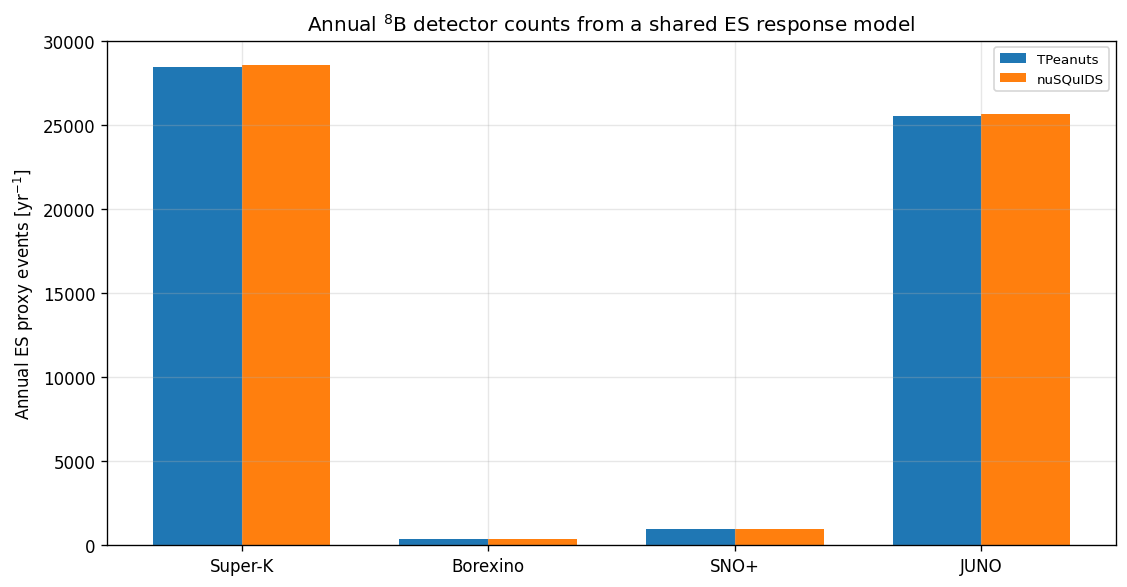

/mnt/v/output/validation/nusquids/vn4_fig61_annual_event_counts.png


In [8]:
count_rows_tp = []
count_rows_nsq = []

for det_name, det in DETECTORS.items():
    n_e = electron_targets(det)
    events_tp = trapezoid(annual_rate_proxy(annual_tp[det_name], E_ANNUAL_MEV), x=E_ANNUAL_MEV) * n_e * SECONDS_PER_YEAR
    events_nsq = trapezoid(annual_rate_proxy(annual_nsq[det_name], E_ANNUAL_MEV), x=E_ANNUAL_MEV) * n_e * SECONDS_PER_YEAR
    count_rows_tp.append({
        "quantity": "annual_events",
        "detector": det_name,
        "annual_events": events_tp,
        "target_electrons": n_e,
    })
    count_rows_nsq.append({
        "quantity": "annual_events",
        "detector": det_name,
        "annual_events": events_nsq,
        "target_electrons": n_e,
    })

count_tp_df = pd.DataFrame.from_records(count_rows_tp)
count_nsq_df = pd.DataFrame.from_records(count_rows_nsq)
count_cmp = scalar_comparison(count_tp_df, count_nsq_df, ["quantity", "detector"], "annual_events")

counts_table = count_tp_df.merge(
    count_nsq_df,
    on=["quantity", "detector", "target_electrons"],
    suffixes=("_tp", "_nsq"),
)
display(counts_table)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
x = np.arange(len(DETECTORS))
width = 0.36
ax.bar(x - 0.5 * width, counts_table["annual_events_tp"], width=width, color="C0", label="TPeanuts")
ax.bar(x + 0.5 * width, counts_table["annual_events_nsq"], width=width, color="C1", label="nuSQuIDS")
ax.set_xticks(x)
ax.set_xticklabels(list(DETECTORS.keys()), rotation=0)
ax.set_ylabel(r"Annual ES proxy events [yr$^{-1}$]")
ax.set_title(r"Annual $^8$B detector counts from a shared ES response model")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("vn4_fig61_annual_event_counts.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

## 7. Export Tables

The notebook exports a combined comparison CSV with the same `max_abs_err` / `max_rel_err`
columns used by the other nuSQuIDS validation notebooks, plus a compact per-section summary.

**Expected results:**
- When nuSQuIDS is installed, the CSV should contain rows for fixed-angle probability,
  annual detector probability, benchmark flux, benchmark rate proxy, and annual counts.
- When nuSQuIDS is unavailable, the exported tables are still written but the comparison
  columns contain `NaN`.

In [9]:
comparison_all = pd.concat(
    [
        fixed_cmp.assign(section="fixed_eta_probability"),
        annual_cmp.assign(section="annual_detector_probability"),
        flux_cmp.assign(section="benchmark_flux_nue"),
        rate_cmp.assign(section="benchmark_rate_proxy"),
        count_cmp.assign(section="annual_events"),
    ],
    ignore_index=True,
    sort=False,
)
comparison_path = OUTPUT_DIR / "vn4_earth_detection_comparison.csv"
comparison_all.to_csv(comparison_path, index=False)

summary_rows = []
for section, df in comparison_all.groupby("section"):
    valid_rel = df["max_rel_err"].dropna()
    valid_abs = df["max_abs_err"].dropna()
    if valid_rel.empty:
        summary_rows.append({
            "section": section,
            "rows": len(df),
            "max_abs_err": np.nan,
            "median_abs_err": np.nan,
            "max_rel_err": np.nan,
            "median_rel_err": np.nan,
            "status": "nuSQuIDS unavailable",
        })
    else:
        max_rel = float(valid_rel.max())
        summary_rows.append({
            "section": section,
            "rows": len(df),
            "max_abs_err": float(valid_abs.max()),
            "median_abs_err": float(valid_abs.median()),
            "max_rel_err": max_rel,
            "median_rel_err": float(valid_rel.median()),
            "status": status_from_rel(max_rel),
        })
summary_df = pd.DataFrame(summary_rows).sort_values("section")
summary_path = OUTPUT_DIR / "vn4_earth_detection_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print(comparison_path)
print(summary_path)

,section,rows,max_abs_err,median_abs_err,max_rel_err,median_rel_err,status
0,annual_detector_probability,72,3.855938e-02,2.875600e-02,1.466397e-01,9.542707e-02,CHECK
1,annual_events,4,1.139459e+02,5.836594e+01,4.445448e-03,3.799951e-03,CHECK
2,benchmark_flux_nue,18,1.725581e+03,3.557427e+02,1.151676e-02,5.076963e-03,CHECK
3,benchmark_rate_proxy,18,1.130743e-40,2.308936e-41,1.130743e-28,2.308936e-29,PASS < ppb
4,fixed_eta_probability,96,4.554645e-02,2.888253e-02,1.480933e-01,9.363204e-02,CHECK


/mnt/v/output/validation/nusquids/vn4_earth_detection_comparison.csv
/mnt/v/output/validation/nusquids/vn4_earth_detection_summary.csv


## 8. Summary

This notebook validates the **Earth-detection stage** of solar neutrinos without mixing in
solar-model differences from the production region. By feeding the **same solar mass
weights** into both backends, the comparison isolates the mapping
$w_i(E) \rightarrow P_\alpha^{\rm det}(E,\eta)$ and its detector-level consequences.

The main physical picture is simple: once the solar state is decohered into vacuum mass
weights, the Earth only reshuffles those weights through matter regeneration. That changes
$P_{ee}$ at the few-percent level across detector latitudes, then the detector response
amplifies the high-energy part of the spectrum because the elastic-scattering cross section
rises with energy.

The event-count prediction in this notebook is a **shared response-model proxy**, not a
native nuSQuIDS detector simulation. Its value is that it translates backend differences
into a directly interpretable detector observable: if the propagated probabilities agree,
then the predicted fluxes and annual counts also agree once the same detector model is
applied.